In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

from paper.style_utils import set_paper_style
set_paper_style()

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%config InlineBackend.figure_format = 'retina'


# FES over RMSD (overlay)

Overlay up to 10 FES profiles from `data/fes_plots` on a single plot.


In [2]:
data_dir = repo_root / 'data' / 'fes_plots'
files = sorted(data_dir.glob('*_FES_RMSD_T340K_nm_KDE.csv'))

def mutant_from_path(path: Path) -> str:
    return path.name.split('_', 1)[0]

selected_mutants = None  # e.g., ['WT', 'D2M', 'Y0A']

if selected_mutants:
    selected = [p for p in files if mutant_from_path(p) in selected_mutants]
else:
    selected = files

def order_selected(paths):
    wt = [p for p in paths if mutant_from_path(p) == 'WT']
    rest = [p for p in paths if mutant_from_path(p) != 'WT']
    return wt + rest

selected = order_selected(selected)[:4]

selected_names = [mutant_from_path(p) for p in selected]
selected_names


['WT', 'D2A', 'D2E', 'D2M']

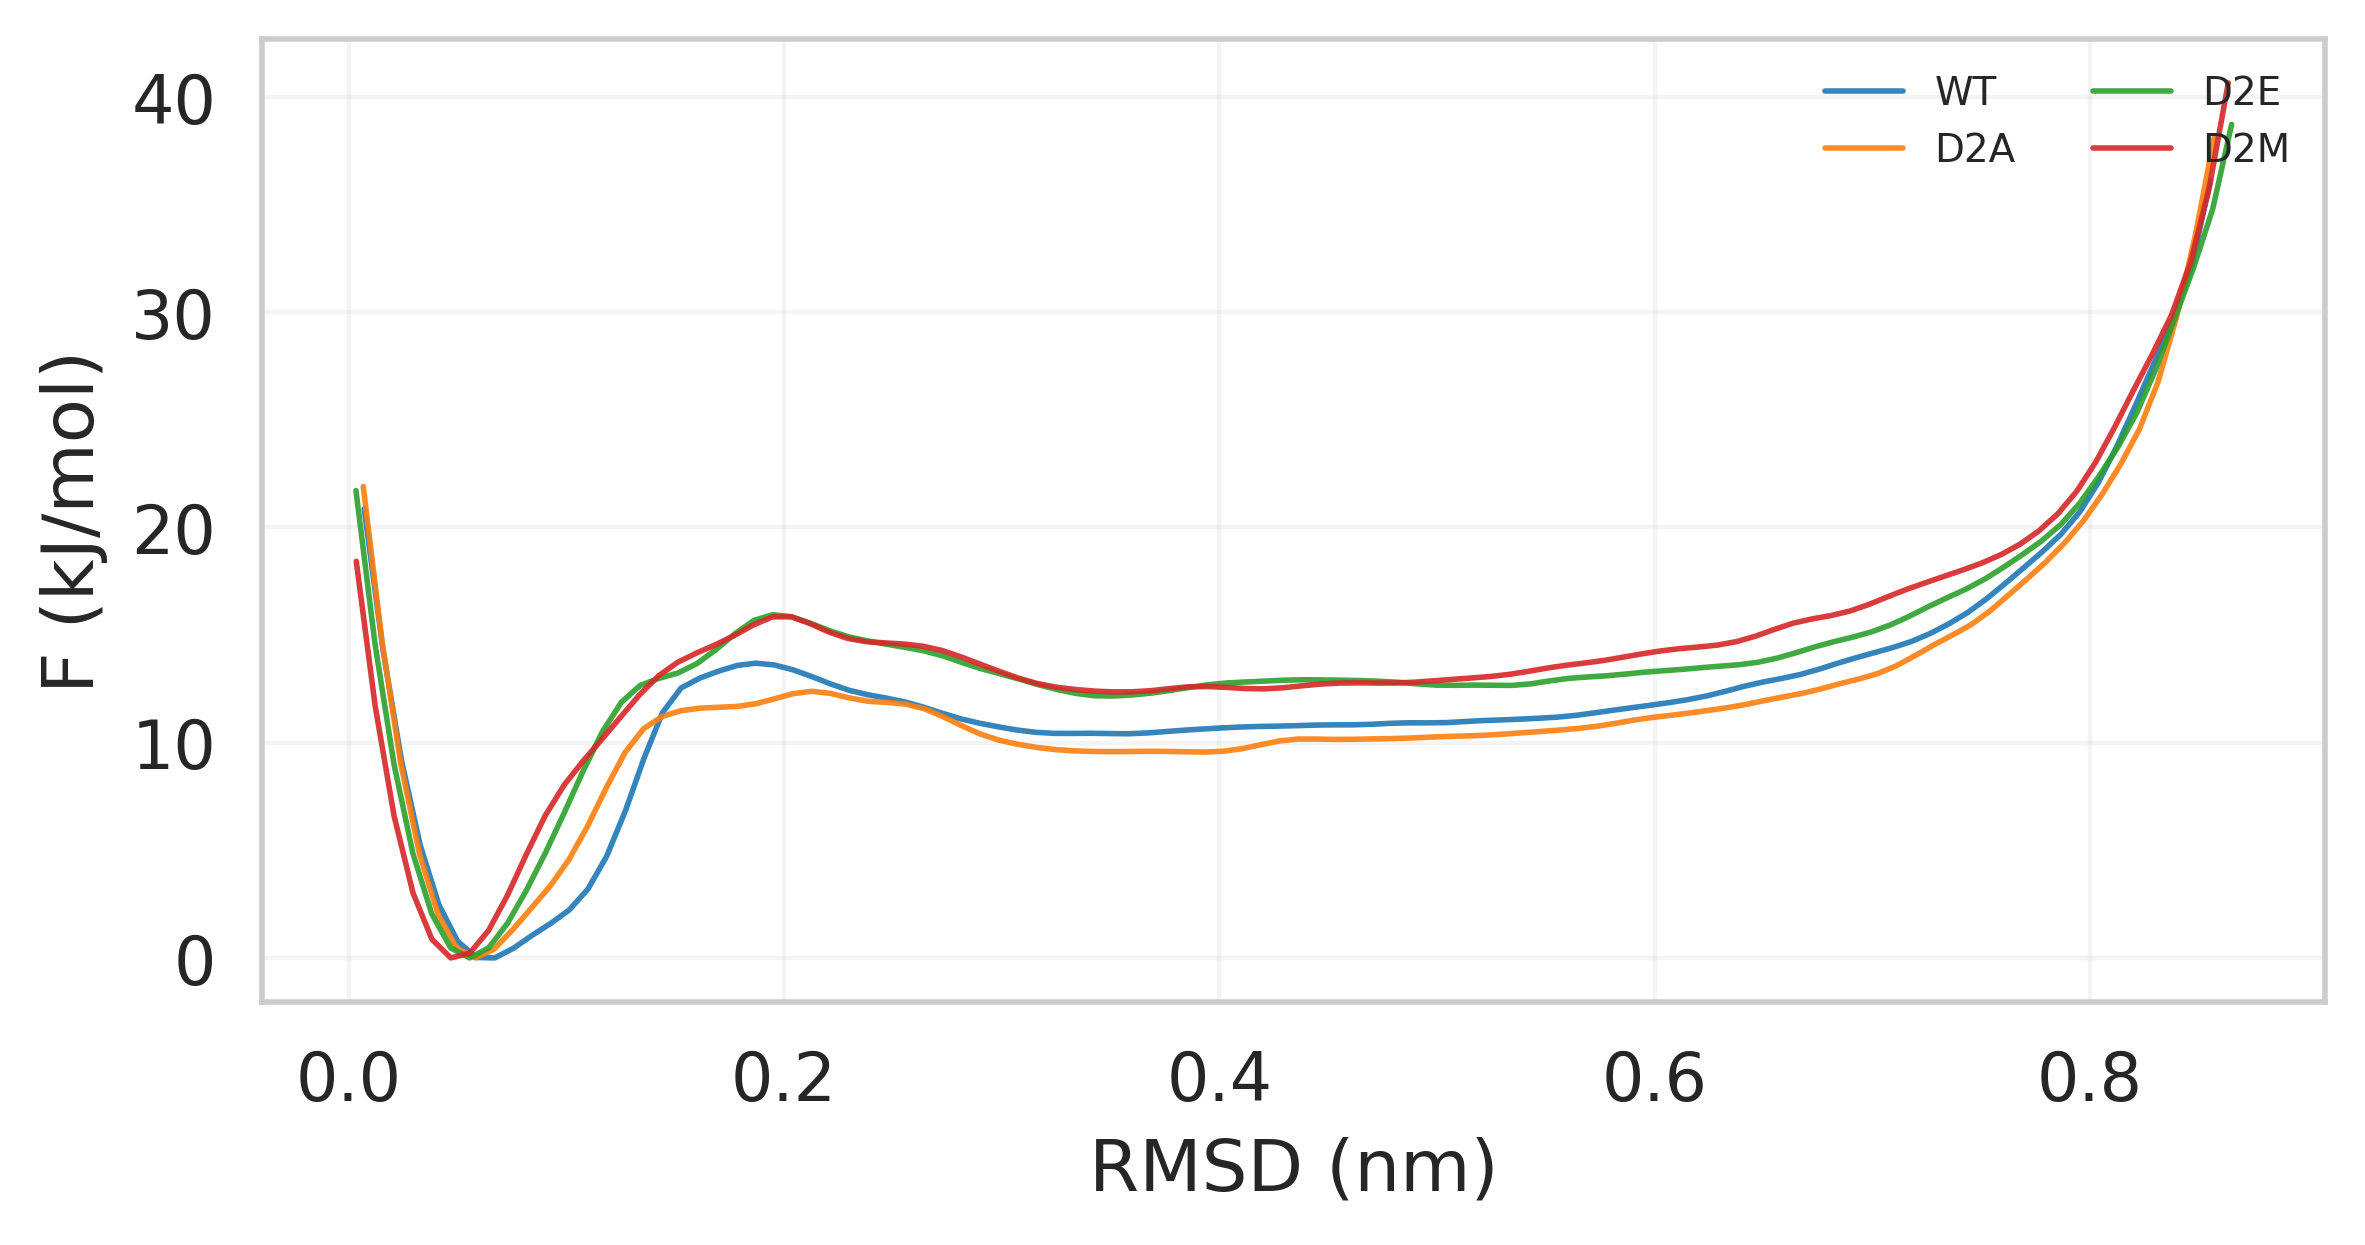

In [3]:
shift_to_min = True

palette = sns.color_palette('tab10', n_colors=len(selected))
fig, ax = plt.subplots(figsize=(6, 3.2), dpi=200)

for (path, name, color) in zip(selected, selected_names, palette):
    df = pd.read_csv(path)
    x = df['RMSD (nm)']
    y = df['F(kJ/mol)']
    if shift_to_min:
        y = y - y.min()
    ax.plot(x, y, lw=1.0, alpha=0.9, color=color, label=name)

ax.set_xlabel('RMSD (nm)')
ax.set_ylabel('F (kJ/mol)')
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=7, ncol=2, loc='upper right')
plt.tight_layout()
